# Modélisation de la Consommation Énergétique des Bâtiments de Seattle

---

## Contexte du Projet

**Objectif** : Prédire la consommation énergétique (`SiteEnergyUse(kBtu)`) des bâtiments non résidentiels de Seattle pour aider la ville à atteindre son objectif de **neutralité carbone en 2050**.

**Données** : Relevés de consommation énergétique des bâtiments de Seattle en 2016

**Méthodologie** :
1. Préparation des données (suppression du data leakage)
2. Analyse des features importantes
3. Sélection des features pertinentes
4. Comparaison de plusieurs algorithmes de régression
5. Évaluation et recommandation

---

## 1. Imports et Configuration

In [1]:
pip install pandas numpy matplotlib scikit-learn category_encoders

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR


# Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# Métriques
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Utilitaires
import time
import warnings
warnings.filterwarnings('ignore')

## 2. Chargement des Données

In [4]:
# Charger les données nettoyées
df_clean = pd.read_pickle('df_clean.pkl')

print("✅ Dataset chargé avec succès")
print(f"📊 Dimensions : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")
print(f"\n📋 Colonnes disponibles :")
print(df_clean.columns.tolist())

✅ Dataset chargé avec succès
📊 Dimensions : 1522 lignes × 34 colonnes

📋 Colonnes disponibles :
['DataYear', 'BuildingType', 'PrimaryPropertyType', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'DefaultData', 'ComplianceStatus', 'TotalGHGEmissions', 'GHGEmissionsIntensity']


In [5]:
# Aperçu rapide des données
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1522 entries, 0 to 3375
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1522 non-null   int64  
 1   BuildingType                     1522 non-null   object 
 2   PrimaryPropertyType              1522 non-null   object 
 3   CouncilDistrictCode              1522 non-null   int64  
 4   Neighborhood                     1522 non-null   object 
 5   Latitude                         1522 non-null   float64
 6   Longitude                        1522 non-null   float64
 7   YearBuilt                        1522 non-null   int64  
 8   NumberofBuildings                1522 non-null   float64
 9   NumberofFloors                   1522 non-null   int64  
 10  PropertyGFATotal                 1522 non-null   int64  
 11  PropertyGFAParking               1522 non-null   int64  
 12  PropertyGFABuilding(s)   

**création d'un dataset model sans valeur manquante.**

## 3. Feature Engineering : création de variables binaires

In [6]:
# ÉTAT INITIAL
print(f"\n📊 ÉTAT INITIAL :")
print(f"   Nombre de lignes : {len(df_clean)}")
print(f"   Nombre de colonnes : {df_clean.shape[1]}")

print("\n2️⃣ TRAITEMENT : Usages secondaires et tertiaires")
print("-"*80)

# Remplir les valeurs manquantes
df_clean['SecondLargestPropertyUseType'] = df_clean['SecondLargestPropertyUseType'].fillna('None')
df_clean['SecondLargestPropertyUseTypeGFA'] = df_clean['SecondLargestPropertyUseTypeGFA'].fillna(0)
df_clean['ThirdLargestPropertyUseType'] = df_clean['ThirdLargestPropertyUseType'].fillna('None')
df_clean['ThirdLargestPropertyUseTypeGFA'] = df_clean['ThirdLargestPropertyUseTypeGFA'].fillna(0)
df_clean['LargestPropertyUseTypeGFA'] = df_clean['LargestPropertyUseTypeGFA'].fillna(0)

print("✅ Rempli les valeurs manquantes de SecondLargestPropertyUseType par 'None'")
print("✅ Rempli les valeurs manquantes de SecondLargestPropertyUseTypeGFA par 0")
print("✅ Rempli les valeurs manquantes de ThirdLargestPropertyUseType par 'None'")
print("✅ Rempli les valeurs manquantes de ThirdLargestPropertyUseTypeGFA par 0")


📊 ÉTAT INITIAL :
   Nombre de lignes : 1522
   Nombre de colonnes : 34

2️⃣ TRAITEMENT : Usages secondaires et tertiaires
--------------------------------------------------------------------------------
✅ Rempli les valeurs manquantes de SecondLargestPropertyUseType par 'None'
✅ Rempli les valeurs manquantes de SecondLargestPropertyUseTypeGFA par 0
✅ Rempli les valeurs manquantes de ThirdLargestPropertyUseType par 'None'
✅ Rempli les valeurs manquantes de ThirdLargestPropertyUseTypeGFA par 0


In [7]:
# Remplir ENERGYSTARScore manquant par 0 
df_clean['ENERGYSTARScore'] = df_clean['ENERGYSTARScore'].fillna(0)

print("✅ Rempli les valeurs manquantes de YearsENERGYSTARCertified None")
print("✅ Rempli les valeurs manquantes de ENERGYSTARScore par 0")

✅ Rempli les valeurs manquantes de YearsENERGYSTARCertified None
✅ Rempli les valeurs manquantes de ENERGYSTARScore par 0


In [8]:
print("\n4️⃣ TRAITEMENT : Sources d'énergie")
print("-"*80)

df_clean['SteamUse(kBtu)'] = df_clean['SteamUse(kBtu)'].fillna(0)
df_clean['NaturalGas(kBtu)'] = df_clean['NaturalGas(kBtu)'].fillna(0)
df_clean['Electricity(kBtu)'] = df_clean['Electricity(kBtu)'].fillna(0)

print(f"   ✅ Rempli les valeurs manquantes de SteamUse(kBtu) par 0")
print(f"   ✅ Rempli les valeurs manquantes de NaturalGas(kBtu) par 0")
print(f"   ✅ Rempli les valeurs manquantes de Electricity(kBtu) par 0")


4️⃣ TRAITEMENT : Sources d'énergie
--------------------------------------------------------------------------------
   ✅ Rempli les valeurs manquantes de SteamUse(kBtu) par 0
   ✅ Rempli les valeurs manquantes de NaturalGas(kBtu) par 0
   ✅ Rempli les valeurs manquantes de Electricity(kBtu) par 0


In [9]:
print("\n6️⃣ TRAITEMENT : Autres colonnes")
print("-"*80)

# LargestPropertyUseType (0.4% manquant) - Remplir les valeurs manquantes de LargestPropertyUseType par PrimaryPropertyType
df_clean['LargestPropertyUseType'] = df_clean['LargestPropertyUseType'].fillna(df_clean['PrimaryPropertyType'])
print("✅ Rempli LargestPropertyUseType avec PrimaryPropertyType")

## NumberofBuildings (0.1% manquant)
if df_clean['NumberofBuildings'].isnull().sum() > 0:
    median_buildings = df_clean['NumberofBuildings'].median()
    df_clean['NumberofBuildings'] = df_clean['NumberofBuildings'].fillna(median_buildings)
    print(f"   ✅ Rempli NumberofBuildings par la médiane ({median_buildings})")

# ListOfAllPropertyUseTypes (0.1% manquant)
if df_clean['ListOfAllPropertyUseTypes'].isnull().sum() > 0:
    lignes_avant = len(df_clean)
    df_clean = df_clean.dropna(subset=['ListOfAllPropertyUseTypes'])
    print(f"   ✅ Supprimé {lignes_avant - len(df_clean)} lignes sans ListOfAllPropertyUseTypes")

# Toutes les autres petites valeurs manquantes
autres_colonnes = ['SiteEnergyUseWN(kBtu)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
                   'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
                   'TotalGHGEmissions', 'GHGEmissionsIntensity']

lignes_avant = len(df_clean)
df_clean = df_clean.dropna(subset=autres_colonnes)
print(f"   ✅ Supprimé {lignes_avant - len(df_clean)} lignes avec autres valeurs manquantes")


6️⃣ TRAITEMENT : Autres colonnes
--------------------------------------------------------------------------------
✅ Rempli LargestPropertyUseType avec PrimaryPropertyType
   ✅ Supprimé 1 lignes avec autres valeurs manquantes


In [10]:
print("\n📊 ÉTAT FINAL :")
print("-"*80)
print(f"   Nombre de lignes : {len(df_clean)}")
print(f"   Nombre de colonnes : {df_clean.shape[1]}")
print(f"   Lignes supprimées au total : {1668 - len(df_clean)}")

# Vérifier s'il reste des valeurs manquantes
valeurs_manquantes_restantes = df_clean.isnull().sum().sum()
print(f"\n   Valeurs manquantes restantes : {valeurs_manquantes_restantes}")

if valeurs_manquantes_restantes == 0:
    print("\n   ✅✅✅ AUCUNE VALEUR MANQUANTE ! Dataset propre ! ✅✅✅")
else:
    print(f"\n   ⚠️ Il reste encore {valeurs_manquantes_restantes} valeurs manquantes")
    print("\n   Colonnes avec valeurs manquantes :")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])


📊 ÉTAT FINAL :
--------------------------------------------------------------------------------
   Nombre de lignes : 1521
   Nombre de colonnes : 34
   Lignes supprimées au total : 147

   Valeurs manquantes restantes : 0

   ✅✅✅ AUCUNE VALEUR MANQUANTE ! Dataset propre ! ✅✅✅


In [11]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1521 entries, 0 to 3375
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1521 non-null   int64  
 1   BuildingType                     1521 non-null   object 
 2   PrimaryPropertyType              1521 non-null   object 
 3   CouncilDistrictCode              1521 non-null   int64  
 4   Neighborhood                     1521 non-null   object 
 5   Latitude                         1521 non-null   float64
 6   Longitude                        1521 non-null   float64
 7   YearBuilt                        1521 non-null   int64  
 8   NumberofBuildings                1521 non-null   float64
 9   NumberofFloors                   1521 non-null   int64  
 10  PropertyGFATotal                 1521 non-null   int64  
 11  PropertyGFAParking               1521 non-null   int64  
 12  PropertyGFABuilding(s)   

## 3/ Mise en Echelle Log les features avec des Outliers

#### 3.1/ Visualisation des features = 0

In [12]:
# Vérification des valeurs nulles ou négatives
print("=== Vérification avant transformation log ===")
print(f"SiteEnergyUse(kBtu) :")
print(f"  - Valeurs = 0 : {(df_clean['SiteEnergyUse(kBtu)'] == 0).sum()}")
print(f"  - Valeurs < 0 : {(df_clean['SiteEnergyUse(kBtu)'] < 0).sum()}")
print(f"  - Valeurs manquantes : {df_clean['SiteEnergyUse(kBtu)'].isna().sum()}")

print(f"\nPropertyGFAParking' :")
print(f"  - Valeurs = 0 : {(df_clean['PropertyGFAParking'] == 0).sum()}")
print(f"  - Valeurs < 0 : {(df_clean['PropertyGFAParking'] < 0).sum()}")
print(f"  - Valeurs manquantes : {df_clean['PropertyGFAParking'].isna().sum()}")

print(f"\nLargestPropertyUseTypeGFA) :")
print(f"  - Valeurs = 0 : {(df_clean['LargestPropertyUseTypeGFA'] == 0).sum()}")
print(f"  - Valeurs < 0 : {(df_clean['LargestPropertyUseTypeGFA'] < 0).sum()}")
print(f"  - Valeurs manquantes : {df_clean['LargestPropertyUseTypeGFA'].isna().sum()}")

print(f"\nSecondLargestPropertyUseTypeGFA:")
print(f"  - Valeurs = 0 : {(df_clean['SecondLargestPropertyUseTypeGFA'] == 0).sum()}")
print(f"  - Valeurs < 0 : {(df_clean['SecondLargestPropertyUseTypeGFA'] < 0).sum()}")
print(f"  - Valeurs manquantes : {df_clean['SecondLargestPropertyUseTypeGFA'].isna().sum()}")

print(f"\nThirdLargestPropertyUseTypeGFA :")
print(f"  - Valeurs = 0 : {(df_clean['ThirdLargestPropertyUseTypeGFA'] == 0).sum()}")
print(f"  - Valeurs < 0 : {(df_clean['ThirdLargestPropertyUseTypeGFA'] < 0).sum()}")
print(f"  - Valeurs manquantes : {df_clean['ThirdLargestPropertyUseTypeGFA'].isna().sum()}")

print(f"\nPropertyGFATotal :")
print(f"  - Valeurs = 0 : {(df_clean['PropertyGFATotal'] == 0).sum()}")
print(f"  - Valeurs < 0 : {(df_clean['PropertyGFATotal'] < 0).sum()}")
print(f"  - Valeurs manquantes : {df_clean['PropertyGFATotal'].isna().sum()}")

print(f"\nPropertyGFABuilding(s) :")
print(f"  - Valeurs = 0 : {(df_clean['PropertyGFABuilding(s)'] == 0).sum()}")
print(f"  - Valeurs < 0 : {(df_clean['PropertyGFABuilding(s)'] < 0).sum()}")
print(f"  - Valeurs manquantes : {df_clean['PropertyGFABuilding(s)'].isna().sum()}")

=== Vérification avant transformation log ===
SiteEnergyUse(kBtu) :
  - Valeurs = 0 : 0
  - Valeurs < 0 : 0
  - Valeurs manquantes : 0

PropertyGFAParking' :
  - Valeurs = 0 : 1196
  - Valeurs < 0 : 0
  - Valeurs manquantes : 0

LargestPropertyUseTypeGFA) :
  - Valeurs = 0 : 4
  - Valeurs < 0 : 0
  - Valeurs manquantes : 0

SecondLargestPropertyUseTypeGFA:
  - Valeurs = 0 : 765
  - Valeurs < 0 : 0
  - Valeurs manquantes : 0

ThirdLargestPropertyUseTypeGFA :
  - Valeurs = 0 : 1201
  - Valeurs < 0 : 0
  - Valeurs manquantes : 0

PropertyGFATotal :
  - Valeurs = 0 : 0
  - Valeurs < 0 : 0
  - Valeurs manquantes : 0

PropertyGFABuilding(s) :
  - Valeurs = 0 : 0
  - Valeurs < 0 : 0
  - Valeurs manquantes : 0


In [13]:
# Création des features en échelle log (log10)

df_clean['SiteEnergyUse(kBtu)_log'] = np.log10(df_clean['SiteEnergyUse(kBtu)'])
df_clean['PropertyGFATotal_log'] = np.log10(df_clean['PropertyGFATotal'])
df_clean['PropertyGFABuilding(s)_log'] = np.log10(df_clean['PropertyGFABuilding(s)'])
df_clean['LargestPropertyUseTypeGFA_log'] = np.log10(df_clean['LargestPropertyUseTypeGFA'])

display(df_clean[['SiteEnergyUse(kBtu)_log','PropertyGFATotal_log','PropertyGFABuilding(s)_log','LargestPropertyUseTypeGFA_log']].describe())

,SiteEnergyUse(kBtu)_log,PropertyGFATotal_log,PropertyGFABuilding(s)_log,LargestPropertyUseTypeGFA_log
count,1521.000000,1521.000000,1521.000000,1521.000000
mean,6.479897,4.788287,4.751268,-inf
std,0.554726,0.412221,0.390073,NaN
min,4.756889,4.052502,3.560624,-inf
25%,6.094355,4.459392,4.444638,4.390935
50%,6.423953,4.678509,4.660325,4.618571
75%,6.844772,5.015217,4.971554,4.950029
max,8.651651,6.342423,6.342423,6.235438


In [14]:
# suppression des Nan
null_SiteEnergyUse =(df_clean['SiteEnergyUse(kBtu)'] == 0).sum()
null_LargestPropertyUseTypeGFA =(df_clean['LargestPropertyUseTypeGFA_log'] == 0).sum()
print(f"On enlève les lignes des features qui sont nulle : {null_SiteEnergyUse} SiteEnergieUse  et {null_LargestPropertyUseTypeGFA}LargestPropertyUseTypeGFA_log ")
df_clean = df_clean[
    (df_clean['SiteEnergyUse(kBtu)'] > 0)&
    (df_clean['LargestPropertyUseTypeGFA_log'] > 0)
    ].copy()
print(f"Nombre de bâtiments après exclusion : {len(df_clean)}")

On enlève les lignes des features qui sont nulle : 0 SiteEnergieUse  et 0LargestPropertyUseTypeGFA_log 
Nombre de bâtiments après exclusion : 1517


In [15]:
display(df_clean[['SiteEnergyUse(kBtu)_log','LargestPropertyUseTypeGFA_log']].describe())

,SiteEnergyUse(kBtu)_log,LargestPropertyUseTypeGFA_log
count,1517.000000,1517.000000
mean,6.480060,4.699434
std,0.555248,0.415147
min,4.756889,3.752509
25%,6.094355,4.397731
50%,6.422734,4.619093
75%,6.847964,4.950365
max,8.651651,6.235438


In [16]:
print("=== Vérification des zéros ===")
print(f"PropertyGFAParking = 0 : {(df_clean['PropertyGFAParking'] == 0).sum()} bâtiments")
print(f"\nTotal bâtiments actuels : {len(df_clean)}")

=== Vérification des zéros ===
PropertyGFAParking = 0 : 1192 bâtiments

Total bâtiments actuels : 1517


## 4. Encodage des variables catégorielles

In [17]:
print("📊 INVENTAIRE DES VARIABLES CATÉGORIELLES")
print("="*80)

# Identifier les colonnes de type 'object' (texte)
colonnes_categorielles = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"\n✅ Nombre de variables catégorielles : {len(colonnes_categorielles)}\n")

# Analyser chaque variable catégorielle
for col in colonnes_categorielles:
    n_categories = df_clean[col].nunique()
    print(f"📌 {col}")
    print(f"   Nombre de catégories : {n_categories}")
    print(f"   Valeurs : {df_clean[col].value_counts().head(5).to_dict()}")
    print()

print("="*80)

📊 INVENTAIRE DES VARIABLES CATÉGORIELLES

✅ Nombre de variables catégorielles : 8

📌 BuildingType
   Nombre de catégories : 5
   Valeurs : {'NonResidential': 1415, 'Nonresidential COS': 79, 'Campus': 12, 'SPS-District K-12': 10, 'Nonresidential WA': 1}

📌 PrimaryPropertyType
   Nombre de catégories : 21
   Valeurs : {'Small- and Mid-Sized Office': 284, 'Other': 236, 'Warehouse': 185, 'Large Office': 167, 'Mixed Use Property': 111}

📌 Neighborhood
   Nombre de catégories : 19
   Valeurs : {'DOWNTOWN': 347, 'GREATER DUWAMISH': 323, 'MAGNOLIA / QUEEN ANNE': 142, 'LAKE UNION': 141, 'EAST': 113}

📌 ListOfAllPropertyUseTypes
   Nombre de catégories : 364
   Valeurs : {'Office': 131, 'Office, Parking': 119, 'Non-Refrigerated Warehouse': 100, 'Non-Refrigerated Warehouse, Office': 61, 'Other': 54}

📌 LargestPropertyUseType
   Nombre de catégories : 55
   Valeurs : {'Office': 481, 'Non-Refrigerated Warehouse': 197, 'Retail Store': 93, 'Other': 90, 'Hotel': 75}

📌 SecondLargestPropertyUseType
   

In [18]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe_cols = ['BuildingType', 'ComplianceStatus']

ohe_encoded = ohe.fit_transform(df_clean[ohe_cols])

ohe_df = pd.DataFrame(
    ohe_encoded,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=df_clean.index
)

binary_cols = [
    'PrimaryPropertyType',
    'Neighborhood',
    'LargestPropertyUseType',
    'SecondLargestPropertyUseType',
    'ThirdLargestPropertyUseType'
]

binary_encoder = BinaryEncoder(cols=binary_cols)

binary_df = binary_encoder.fit_transform(df_clean[binary_cols])

df_clean = df_clean.drop(
    columns=ohe_cols + binary_cols + ['ListOfAllPropertyUseTypes']
)

df_clean = pd.concat(
    [df_clean, ohe_df, binary_df],
    axis=1
)

## 5. Features supplémentaires : RATIOS ET PROPORTIONS
création de 7 ratios :
- **building_age** : age des bâtiments
- **parking_ratio** surfaceparking/surface total
- **main_use_ratio** type d'utilisation/surface total
- **energie_ratio** ratio type energie (pour le calcul de ratio des 3 features energies)
- **Electricity(kBtu)_ratio** = ratio electricité
- **SteamUse(kBtu)_ratio** = ratio steamUse
- **NaturalGas(kBtu)_ratio** = ratio gaz
- **second_use_ratio**  2nd utilisation surface /surface total
- **third_use_ratio**  3e utilisation surface /surface total
- **usable_area**: surface totale - surfaceParking

In [19]:
# 1. RATIOS surfaceparking/surface total et type d'utilisation/surface total
df_clean['building_age'] = df_clean['DataYear'] - df_clean['YearBuilt']
df_clean['parking_ratio'] = df_clean['PropertyGFAParking'] / df_clean['PropertyGFATotal']

#ratio Energie
df_clean['totale_energie'] = df_clean['Electricity(kBtu)'] + df_clean['SteamUse(kBtu)'] + df_clean['NaturalGas(kBtu)']
df_clean['Electricity(kBtu)_ratio'] = df_clean['Electricity(kBtu)'] / df_clean['totale_energie']
df_clean['SteamUse(kBtu)_ratio'] = df_clean['SteamUse(kBtu)'] / df_clean['totale_energie']
df_clean['NaturalGas(kBtu)_ratio'] = df_clean['NaturalGas(kBtu)'] / df_clean['totale_energie']

#ratio d'utilisation
df_clean['main_use_ratio'] = df_clean['LargestPropertyUseTypeGFA'] / df_clean['PropertyGFATotal']
df_clean['second_use_ratio'] = df_clean['SecondLargestPropertyUseTypeGFA'] / df_clean['PropertyGFATotal']
df_clean['third_use_ratio'] = df_clean['ThirdLargestPropertyUseTypeGFA'] / df_clean['PropertyGFATotal']
df_clean['usable_area'] = df_clean['PropertyGFATotal'] - df_clean['PropertyGFAParking']

display(df_clean[['building_age','parking_ratio','second_use_ratio','third_use_ratio','usable_area','Electricity(kBtu)_ratio','SteamUse(kBtu)_ratio','NaturalGas(kBtu)_ratio','main_use_ratio']].describe())

,building_age,parking_ratio,second_use_ratio,third_use_ratio,usable_area,Electricity(kBtu)_ratio,SteamUse(kBtu)_ratio,NaturalGas(kBtu)_ratio,main_use_ratio
count,1517.000000,1517.000000,1517.000000,1517.000000,1.517000e+03,1516.000000,1516.000000,1516.000000,1517.000000
mean,54.532630,0.065725,0.130944,0.023330,9.746246e+04,0.704512,0.022516,0.272972,0.857378
std,32.938133,0.144240,0.173784,0.064044,1.660636e+05,0.263110,0.094483,0.264325,0.299980
min,1.000000,0.000000,0.000000,0.000000,3.636000e+03,0.000000,0.000000,0.000000,0.186469
25%,28.000000,0.000000,0.000000,0.000000,2.780000e+04,0.491798,0.000000,0.000000,0.668946
50%,51.000000,0.000000,0.000000,0.000000,4.570000e+04,0.713513,0.000000,0.229255,0.933750
75%,87.000000,0.000000,0.250000,0.000000,9.366000e+04,1.000000,0.000000,0.489226,1.000000
max,116.000000,0.895023,1.452054,0.929094,2.200000e+06,1.000000,0.766988,1.000000,6.426849


In [20]:
df_clean['Electricity(kBtu)_ratio'] = df_clean['Electricity(kBtu)_ratio'].fillna(0)
df_clean['SteamUse(kBtu)_ratio'] = df_clean['SteamUse(kBtu)_ratio'].fillna(0)
df_clean['NaturalGas(kBtu)_ratio'] = df_clean['NaturalGas(kBtu)_ratio'].fillna(0)

In [21]:
#valeur manquante
print(f"\n 'Electricity(kBtu)_ratio' :")
print(f"  - Valeurs = 0 : {(df_clean['Electricity(kBtu)_ratio'] == 0).sum()}")
print(f"  - Valeurs < 0 : {(df_clean['Electricity(kBtu)_ratio'] < 0).sum()}")
print(f"  - Valeurs manquantes : {df_clean['Electricity(kBtu)_ratio'].isna().sum()}")

print(f"\n 'SteamUse(kBtu)_ratio' :")
print(f"  - Valeurs = 0 : {(df_clean['SteamUse(kBtu)_ratio'] == 0).sum()}")
print(f"  - Valeurs < 0 : {(df_clean['SteamUse(kBtu)_ratio'] < 0).sum()}")
print(f"  - Valeurs manquantes : {df_clean['SteamUse(kBtu)_ratio'].isna().sum()}")

print(f"\n 'NaturalGas(kBtu)_ratio' :")
print(f"  - Valeurs = 0 : {(df_clean['NaturalGas(kBtu)_ratio'] == 0).sum()}")
print(f"  - Valeurs < 0 : {(df_clean['NaturalGas(kBtu)_ratio'] < 0).sum()}")
print(f"  - Valeurs manquantes : {df_clean['NaturalGas(kBtu)_ratio'].isna().sum()}")


 'Electricity(kBtu)_ratio' :
  - Valeurs = 0 : 2
  - Valeurs < 0 : 0
  - Valeurs manquantes : 0

 'SteamUse(kBtu)_ratio' :
  - Valeurs = 0 : 1407
  - Valeurs < 0 : 0
  - Valeurs manquantes : 0

 'NaturalGas(kBtu)_ratio' :
  - Valeurs = 0 : 441
  - Valeurs < 0 : 0
  - Valeurs manquantes : 0


In [22]:
print(f"Le nouveau dataset est composé de {df_clean.shape[0]} lignes et de {df_clean.shape[1]} colonnes" )
print(df_clean.info())

Le nouveau dataset est composé de 1517 lignes et de 74 colonnes
<class 'pandas.core.frame.DataFrame'>
Index: 1517 entries, 0 to 3375
Data columns (total 74 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1517 non-null   int64  
 1   CouncilDistrictCode              1517 non-null   int64  
 2   Latitude                         1517 non-null   float64
 3   Longitude                        1517 non-null   float64
 4   YearBuilt                        1517 non-null   int64  
 5   NumberofBuildings                1517 non-null   float64
 6   NumberofFloors                   1517 non-null   int64  
 7   PropertyGFATotal                 1517 non-null   int64  
 8   PropertyGFAParking               1517 non-null   int64  
 9   PropertyGFABuilding(s)           1517 non-null   int64  
 10  LargestPropertyUseTypeGFA        1517 non-null   float64
 11  SecondLargestPropertyUs

**Analyse**  
Il y a une corrélation entre la surface et la consommation.
Il n'y a pas très peu de corrélation entre l'année de constructions et la consommations 

Décision d'encodage pour chaque variable :

    OneHotEncoder : BuildingType ; ComplianceStatus / car peu de catégories
    BinaryEncoder : PrimaryPropertyType ; Neighborhood ; LargestPropertyUseType ; SecondLargestPropertyUseType; ThirdLargestPropertyUseType
    pour ListOfAllPropertyUseTypes, il y a trop de catégorie (371) donc on ne l'utilisera pas.



In [23]:
print(f"Après la suppression des Outlier. Le nouveau dataset est composé de {df_clean.shape[0]} lignes et de {df_clean.shape[1]} colonnes" )

Après la suppression des Outlier. Le nouveau dataset est composé de 1517 lignes et de 74 colonnes


## Préparation des Données

### 3.1 Suppression des colonnes pour éviter le Data Leakage

**Colonnes à supprimer** :
- Variables calculées à partir de la target (EUI, etc.)
- Composantes de la consommation (Electricity, Gas, Steam)
- Émissions de GES (liées directement à la consommation)

In [24]:
colonnes_a_supprimer = [
    # Variables calculées à partir de la target
    'SiteEUI(kBtu/sf)',
    'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)',
    'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUseWN(kBtu)',
    
    # Composantes de la consommation (= data leakage direct)
    'Electricity(kBtu)',
    'NaturalGas(kBtu)',
    'SteamUse(kBtu)',
    
    # Émissions (liées directement à la consommation)
    'TotalGHGEmissions',
    'GHGEmissionsIntensity',
]

# Créer le dataset pour la modélisation
df_model = df_clean.drop(columns=colonnes_a_supprimer)

print(f"✅ Colonnes supprimées : {len(colonnes_a_supprimer)}")
print(f"📊 Nouvelles dimensions : {df_model.shape}")

✅ Colonnes supprimées : 10
📊 Nouvelles dimensions : (1517, 64)


## 6. Matrice de Correlations

**Objectif** : Identifier les features les plus prédictives pour simplifier le modèle.


✅ Matrice calculée pour 38 variables UTILISABLES


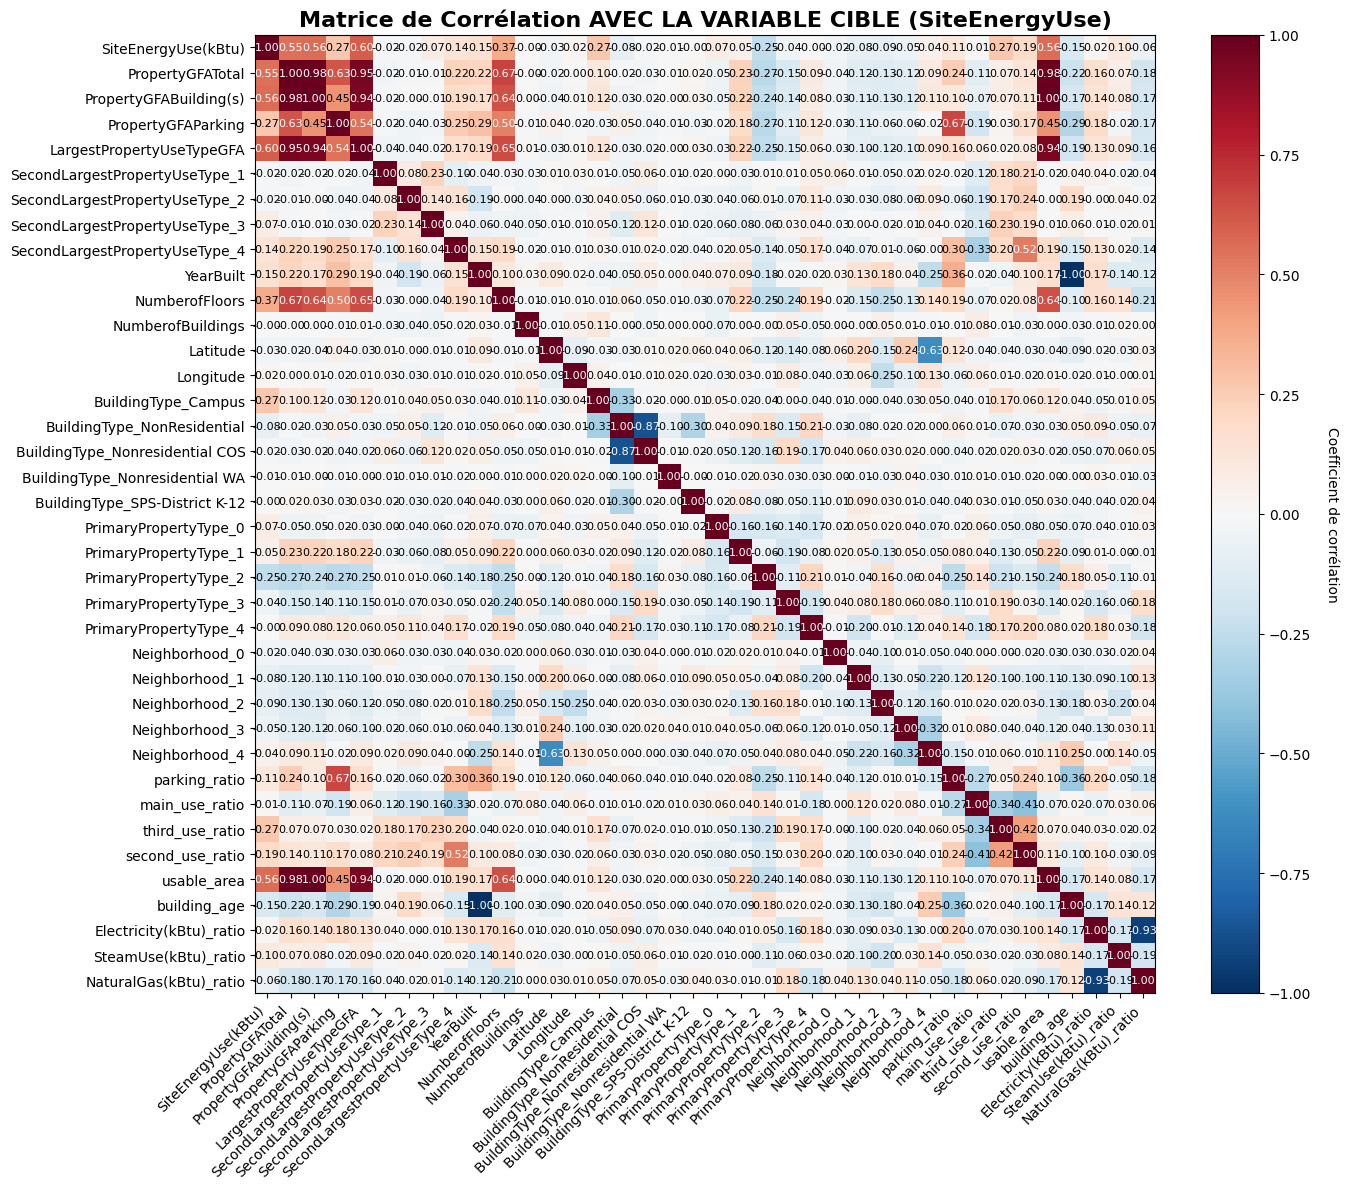



🎯 CORRÉLATIONS AVEC LA VARIABLE CIBLE (SiteEnergyUse)
   Variables structurelles UNIQUEMENT - utilisables pour la prédiction
--------------------------------------------------------------------------------

📈 Top TOUTES les corrélations (ordre décroissant) :
    1. LargestPropertyUseTypeGFA                : +0.603  [MOYENNE   ]
    2. usable_area                              : +0.562  [MOYENNE   ]
    3. PropertyGFABuilding(s)                   : +0.562  [MOYENNE   ]
    4. PropertyGFATotal                         : +0.553  [MOYENNE   ]
    5. NumberofFloors                           : +0.373  [FAIBLE    ]
    6. BuildingType_Campus                      : +0.272  [FAIBLE    ]
    7. third_use_ratio                          : +0.270  [FAIBLE    ]
    8. PropertyGFAParking                       : +0.269  [FAIBLE    ]
    9. second_use_ratio                         : +0.193  [FAIBLE    ]
   10. YearBuilt                                : +0.149  [FAIBLE    ]
   11. SecondLargestPropertyU

In [25]:
colonnes_importantes = [
    'SiteEnergyUse(kBtu)',           # Variable cible
    'PropertyGFATotal',              # Surface totale
    'PropertyGFABuilding(s)',        # Surface bâtiment
    'PropertyGFAParking',            # Surface parking
    'LargestPropertyUseTypeGFA',     # Surface usage principal
    'SecondLargestPropertyUseType_1',
    'SecondLargestPropertyUseType_2', 
    'SecondLargestPropertyUseType_3',
    'SecondLargestPropertyUseType_4',
    'YearBuilt',                     # Année construction
    'NumberofFloors',                # Nombre d'étages
    'NumberofBuildings',             # Nombre de bâtiments
    'Latitude',                      # Position géographique
    'Longitude',                      # Position géographique
    'BuildingType_Campus',                            
    'BuildingType_NonResidential',                   
    'BuildingType_Nonresidential COS',                
    'BuildingType_Nonresidential WA',                 
    'BuildingType_SPS-District K-12', 
    'PrimaryPropertyType_0',
    'PrimaryPropertyType_1',
    'PrimaryPropertyType_2',
    'PrimaryPropertyType_3',
    'PrimaryPropertyType_4',
    'Neighborhood_0',
    'Neighborhood_1', 
    'Neighborhood_2', 
    'Neighborhood_3', 
    'Neighborhood_4', 
    'parking_ratio',                   #nouvelle variables
    'main_use_ratio',             
    'third_use_ratio',
    'second_use_ratio',
    'usable_area', 
    'building_age',
    'Electricity(kBtu)_ratio',
    'SteamUse(kBtu)_ratio',
    'NaturalGas(kBtu)_ratio'
]

# Créer un sous-dataframe avec ces colonnes
df_colonne = df_clean[colonnes_importantes].copy()

# Calculer la matrice de corrélation
correlation_matrix = df_colonne.corr()

print(f"\n✅ Matrice calculée pour {len(colonnes_importantes)} variables UTILISABLES")

# Créer la visualisation
fig, ax = plt.subplots(figsize=(14, 12))

# Créer la heatmap
im = ax.imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

# Ajouter les labels
ax.set_xticks(np.arange(len(colonnes_importantes)))
ax.set_yticks(np.arange(len(colonnes_importantes)))
ax.set_xticklabels(colonnes_importantes, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(colonnes_importantes, fontsize=10)

# Ajouter les valeurs dans chaque case
for i in range(len(colonnes_importantes)):
    for j in range(len(colonnes_importantes)):
        value = correlation_matrix.iloc[i, j]
        text_color = 'white' if abs(value) > 0.5 else 'black'
        text = ax.text(j, i, f'{value:.2f}', 
                      ha="center", va="center", color=text_color, fontsize=8)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Coefficient de corrélation', rotation=270, labelpad=20)

# Titre
ax.set_title('Matrice de Corrélation AVEC LA VARIABLE CIBLE (SiteEnergyUse)', 
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)

# Analyser les corrélations avec la variable cible
print("\n🎯 CORRÉLATIONS AVEC LA VARIABLE CIBLE (SiteEnergyUse)")
print("   Variables structurelles UNIQUEMENT - utilisables pour la prédiction")
print("-"*80)

target_correlations = correlation_matrix['SiteEnergyUse(kBtu)'].drop('SiteEnergyUse(kBtu)').sort_values(ascending=False)

print("\n📈 Top TOUTES les corrélations (ordre décroissant) :")
for i, (var, corr) in enumerate(target_correlations.items(), 1):
    # Interpréter la force
    if abs(corr) > 0.7:
        force = "FORTE     "
    elif abs(corr) > 0.4:
        force = "MOYENNE   "
    else:
        force = "FAIBLE    "
    
    print(f"   {i:2d}. {var:40s} : {corr:+.3f}  [{force}]")

print("="*80)

### 3.2 Séparation Features (X) et Target (y)

In [26]:
# Séparer features et target
X = df_model.drop(columns=['SiteEnergyUse(kBtu)_log'])
y = df_model['SiteEnergyUse(kBtu)_log']

print("✅ Séparation effectuée")
print(f"📊 X (features) : {X.shape}")
print(f"🎯 y (target) : {y.shape}")
print(f"\n📋 Features disponibles ({X.shape[1]}) :")
print(X.columns.tolist())

✅ Séparation effectuée
📊 X (features) : (1517, 63)
🎯 y (target) : (1517,)

📋 Features disponibles (63) :
['DataYear', 'CouncilDistrictCode', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEnergyUse(kBtu)', 'DefaultData', 'PropertyGFATotal_log', 'PropertyGFABuilding(s)_log', 'LargestPropertyUseTypeGFA_log', 'BuildingType_Campus', 'BuildingType_NonResidential', 'BuildingType_Nonresidential COS', 'BuildingType_Nonresidential WA', 'BuildingType_SPS-District K-12', 'ComplianceStatus_Compliant', 'PrimaryPropertyType_0', 'PrimaryPropertyType_1', 'PrimaryPropertyType_2', 'PrimaryPropertyType_3', 'PrimaryPropertyType_4', 'Neighborhood_0', 'Neighborhood_1', 'Neighborhood_2', 'Neighborhood_3', 'Neighborhood_4', 'LargestPropertyUseType_0', 'LargestPropertyUseType_1', 'LargestProper

## 8/ Sélection des Features

In [27]:
# Sélection des 5 features principales
features_selectionnees_SVR = [
    'PropertyGFATotal_log',
    'LargestPropertyUseTypeGFA_log',
    'main_use_ratio',
    'building_age',
    'NumberofFloors'
]

features_selectionnees = [
    'PropertyGFATotal_log',              # Surface totale en echelle log
    'PropertyGFABuilding(s)_log',        # Surface bâtiment en echelle log
    'PropertyGFAParking',            # Surface parking
    'LargestPropertyUseTypeGFA_log',     # Surface usage principal en echelle log
    'SecondLargestPropertyUseTypeGFA', # Surface usage secondaire
    'ThirdLargestPropertyUseTypeGFA',  # Surface usage tertiaire
    'SecondLargestPropertyUseType_1',
    'SecondLargestPropertyUseType_2', 
    'SecondLargestPropertyUseType_3',
    'SecondLargestPropertyUseType_4',
    'NumberofFloors',                # Nombre d'étages
    'NumberofBuildings',             # Nombre de bâtiments
    'Latitude',                      # Position géographique
    'Longitude',                      # Position géographique
    'BuildingType_Campus',                            
    'BuildingType_NonResidential',                   
    'BuildingType_Nonresidential COS',                
    'BuildingType_Nonresidential WA',                 
    'BuildingType_SPS-District K-12', 
    'PrimaryPropertyType_0',
    'PrimaryPropertyType_1',
    'PrimaryPropertyType_2',
    'PrimaryPropertyType_3',
    'PrimaryPropertyType_4',
    'Neighborhood_0',
    'Neighborhood_1', 
    'Neighborhood_2', 
    'Neighborhood_3', 
    'Neighborhood_4', 
    'parking_ratio',                   
    'main_use_ratio',              
    'third_use_ratio',
    'second_use_ratio',
    'usable_area', 
    'building_age',
    'Electricity(kBtu)_ratio',
    'SteamUse(kBtu)_ratio',
    'NaturalGas(kBtu)_ratio'
]

# Créer le nouveau dataset simplifié
X_svr = df_model[features_selectionnees_SVR]
y_svr = df_model['SiteEnergyUse(kBtu)_log']

X = df_model[features_selectionnees]
y = df_model['SiteEnergyUse(kBtu)_log']

In [28]:
X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(
    X_svr, 
    y_svr, 
    test_size=0.2, 
    random_state=42
)

# Split Train/Test pour les modèles Random Forest et Linear Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print("✅ Split effectué")
print(f"📊 Ensemble d'entraînement : {X_train.shape[0]} lignes")
print(f"📊 Ensemble de test : {X_test.shape[0]} lignes")

✅ Split effectué
📊 Ensemble d'entraînement : 1213 lignes
📊 Ensemble de test : 304 lignes


## 9/ GridSearch CV

In [29]:
# Standardiser AVANT le GridSearch
scaler_svr = StandardScaler()
X_train_svr_scaled = scaler_svr.fit_transform(X_train_svr)
X_test_svr_scaled = scaler_svr.transform(X_test_svr)

# Grille de paramètres
param_grid = {
    'kernel': ['linear'],
    'C': [1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

# Relancer le GridSearch avec les données standardisées
grid_search.fit(X_train_svr_scaled, y_train_svr)

# Résultats
print("\n✅ GridSearch terminé !")
print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score R² (CV) : {grid_search.best_score_:.4f}")

# Récupérer le meilleur modèle SVR
best_svr = grid_search.best_estimator_

print("="*110)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ GridSearch terminé !
Meilleurs paramètres : {'C': 1, 'epsilon': 0.1, 'kernel': 'linear'}
Meilleur score R² (CV) : 0.5856


## 10. Modélisation et Comparaison d'Algorithmes

**Approche méthodologique** : Tester plusieurs algorithmes du plus simple au plus complexe.

**Algorithmes testés** :
1. **Dummy Regressor** (baseline) - Prédit toujours la moyenne
2. **Linear Regression** - Relation linéaire simple
3. **SVR** (Support Vector Regression) - Relation non-linéaire
4. **Random Forest** - Ensemble d'arbres de décision

**Métriques d'évaluation** :
- **R²** : Coefficient de détermination (0 à 1, plus c'est élevé, mieux c'est)
- **RMSE** : Erreur quadratique moyenne (en kBtu)
- **MAE** : Erreur absolue moyenne (en kBtu)
- **MAPE** : Erreur absolue moyenne en pourcentage

In [30]:
modeles = {
    'Dummy (Baseline)': Pipeline([
        ('model', DummyRegressor(strategy='mean'))
    ]),

    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'SVR': Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='linear', C=1, epsilon=0.01))
]),

    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(
            n_estimators=50,
            max_depth=8,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42
        ))
])
}

resultats = []

for nom, pipeline in modeles.items():
    print(f"\n🔧 Entraînement : {nom}")
    
    # Mesurer le temps d'entraînement
    start_time = time.time()
    
    # Entraîner le modèle
    pipeline.fit(X_train, y_train)
    
    # Temps d'entraînement
    train_time = round(time.time() - start_time,4)
    
    # Prédictions
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
   # Calcul des métriques pour TRAIN
    r2_train = round(r2_score(y_train, y_pred_train),4)
    mae_train = round(mean_absolute_error(y_train, y_pred_train),1)
    mse_train = round(mean_squared_error(y_train, y_pred_train),1)  
    rmse_train = round(np.sqrt(mse_train),1) 

    # Calcul des métriques pour TEST
    r2_test = round(r2_score(y_test, y_pred_test),2)
    ecart_R2 = round(r2_train - r2_test,4)
    mae_test = round(mean_absolute_error(y_test, y_pred_test),2)
    mse_test = round(mean_squared_error(y_test, y_pred_test),2)  
    rmse_test = round(np.sqrt(mse_test),2) 
    
    # MAPE (en évitant les divisions par zéro)
    mask = y_test != 0
    mape = round(np.mean(np.abs((y_test[mask] - y_pred_test[mask]) / y_test[mask])) * 100,1)
    
    # Stocker les résultats
    resultats.append({
        'Modèle': nom,
        'Temps (s)': train_time,
        'R² Train': r2_train,
        'R² Test': r2_test,
        'Ecart R²' : ecart_R2,
        'MAE Train': mae_train,
        'MAE Test': mae_test,
        'RMSE Train': rmse_train,
        'RMSE Test': rmse_test,
        'MAPE (%)': mape
    })
    
   
    # Création d'un tableau comparatif
    resultats_df = pd.DataFrame(resultats).sort_values('R² Test', ascending=False)

print("\n📊 TABLEAU COMPARATIF DES MODÈLES")
print("="*110)
print(resultats_df.to_string(index=False))
print("="*110)
  
print("\n✅ ENTRAÎNEMENT TERMINÉ !")


🔧 Entraînement : Dummy (Baseline)

🔧 Entraînement : Linear Regression

🔧 Entraînement : SVR

🔧 Entraînement : Random Forest

📊 TABLEAU COMPARATIF DES MODÈLES
           Modèle  Temps (s)  R² Train  R² Test  Ecart R²  MAE Train  MAE Test  RMSE Train  RMSE Test  MAPE (%)
    Random Forest     1.5193    0.8194     0.72    0.0994        0.2      0.22         0.3       0.30       3.5
Linear Regression     0.0462    0.7331     0.71    0.0231        0.2      0.23         0.3       0.30       3.6
              SVR     3.8260    0.7249     0.71    0.0149        0.2      0.22         0.3       0.30       3.6
 Dummy (Baseline)     0.0022    0.0000    -0.00    0.0000        0.4      0.44         0.5       0.56       6.9

✅ ENTRAÎNEMENT TERMINÉ !


**analyse**
Le métriques MAE et RMSE sont proches de zéro.
La moyenne des erreurs (MAE) est basse (inférieur à 5)
Nos 3 modèles font mieux que la Baseline.

Le modèle **Linear Regression** parait meilleur :
- Rapide : 0.0682
- Un écart des deux R² est de 0.O323
 

## 11. Résultats et Comparaison

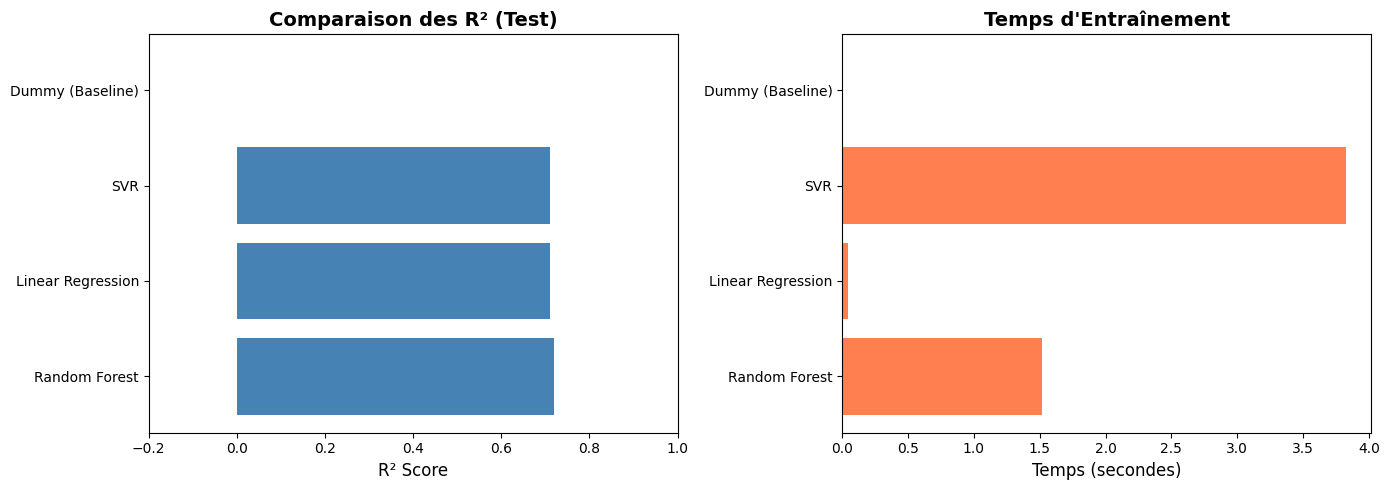

In [31]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Score comparison
axes[0].barh(resultats_df['Modèle'], resultats_df['R² Test'], color='steelblue')
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].set_title('Comparaison des R² (Test)', fontsize=14, fontweight='bold')
axes[0].set_xlim(-0.2, 1.0)

# Temps d'entraînement
axes[1].barh(resultats_df['Modèle'], resultats_df['Temps (s)'], color='coral')
axes[1].set_xlabel('Temps (secondes)', fontsize=12)
axes[1].set_title('Temps d\'Entraînement', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Visualisation de la Prédiction

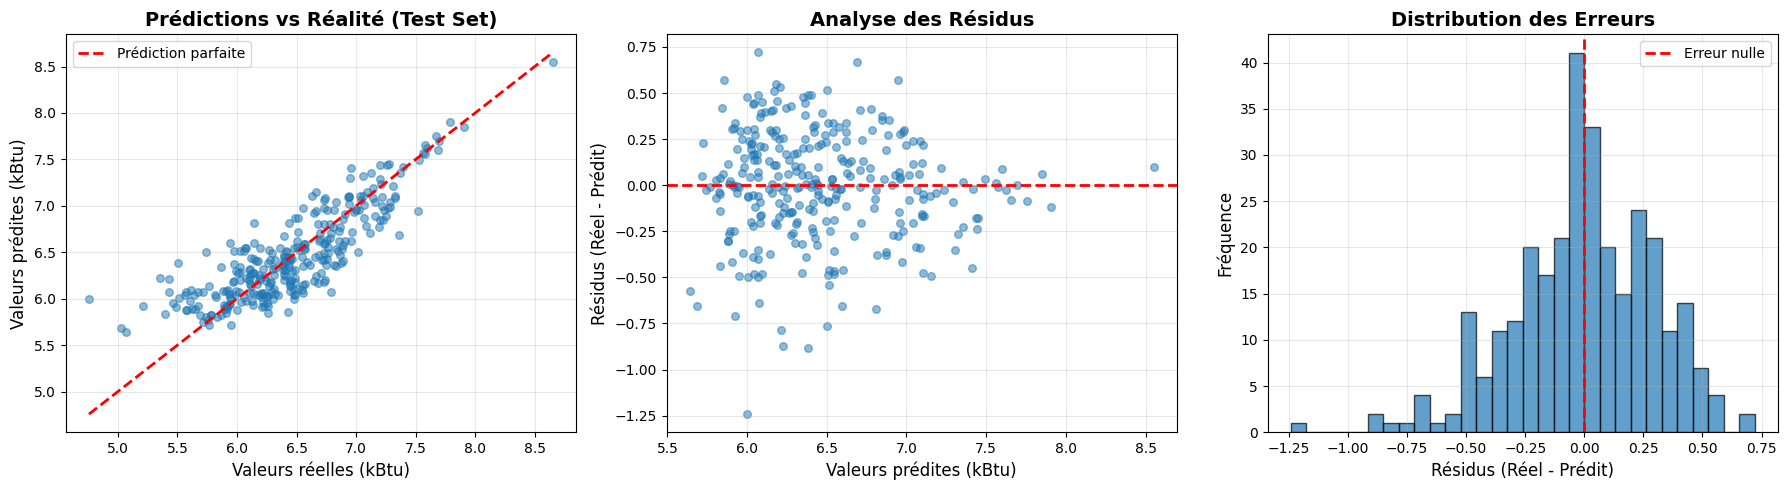

In [32]:
# Récupérer le modèle Linear Regression entraîné
lr_model = modeles['Linear Regression']

# Faire les prédictions (si pas déjà fait)
y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)

# Créer une figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================================
# 1️⃣ GRAPHIQUE 1 : Valeurs réelles vs Prédictions (TEST)
# ============================================================
axes[0].scatter(y_test, y_pred_test_lr, alpha=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles (kBtu)', fontsize=12)
axes[0].set_ylabel('Valeurs prédites (kBtu)', fontsize=12)
axes[0].set_title('Prédictions vs Réalité (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ============================================================
# 2️⃣ GRAPHIQUE 2 : Résidus (erreurs de prédiction)
# ============================================================
residus = y_test - y_pred_test_lr
axes[1].scatter(y_pred_test_lr, residus, alpha=0.5, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Valeurs prédites (kBtu)', fontsize=12)
axes[1].set_ylabel('Résidus (Réel - Prédit)', fontsize=12)
axes[1].set_title('Analyse des Résidus', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# ============================================================
# 3️⃣ GRAPHIQUE 3 : Distribution des erreurs
# ============================================================
axes[2].hist(residus, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', lw=2, label='Erreur nulle')
axes[2].set_xlabel('Résidus (Réel - Prédit)', fontsize=12)
axes[2].set_ylabel('Fréquence', fontsize=12)
axes[2].set_title('Distribution des Erreurs', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Analyse**
Prédictions vs Réalité : l'ensemble des points sont proches de la ligne rouge qui représente la prédiction idéale
Analyse des résidus: les points ne forment pas de schéma précis.
Distribution des Erreurs : graphique sous forme de cloche, proche de zéro.

## 13/ Les features importantes

📊 TOP 10 FEATURES - XGBOOST (Feature Importance)
                        Feature  Importance
          PrimaryPropertyType_0    0.204538
          PrimaryPropertyType_2    0.152218
           PropertyGFATotal_log    0.134855
          PrimaryPropertyType_3    0.125614
    BuildingType_NonResidential    0.041786
 SecondLargestPropertyUseType_3    0.025650
        Electricity(kBtu)_ratio    0.023526
     PropertyGFABuilding(s)_log    0.020675
          PrimaryPropertyType_1    0.019502
BuildingType_Nonresidential COS    0.018619


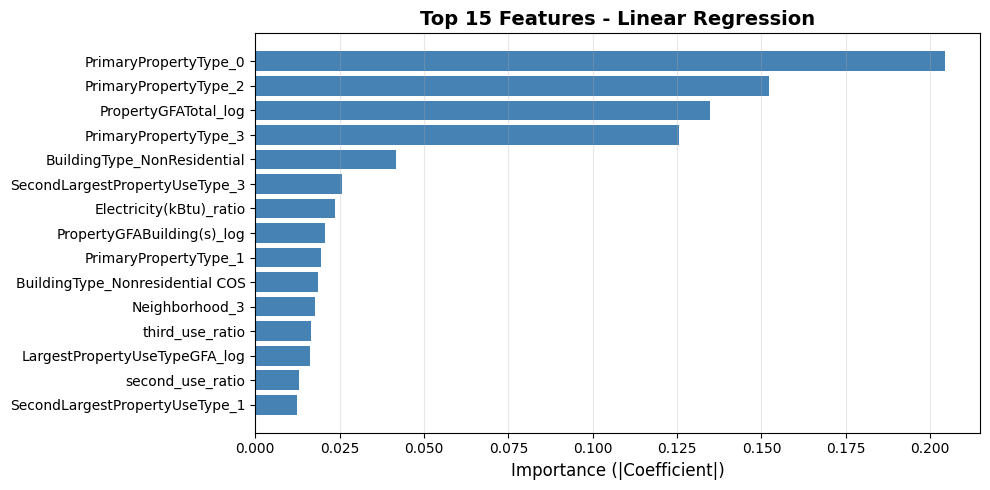

In [33]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline  
from sklearn.preprocessing import StandardScaler 

# Version simplifiée (recommandée)
modeles['XGBoost'] = XGBRegressor(random_state=42, n_estimators=100)
modeles['XGBoost'].fit(X_train, y_train)

# Extraire les feature importances directement
importances_xgb = modeles['XGBoost'].feature_importances_

# Créer le DataFrame
importance_xgb = pd.DataFrame({
    'Feature': features_selectionnees,
    'Importance': importances_xgb
}).sort_values('Importance', ascending=False)

print("📊 TOP 10 FEATURES - XGBOOST (Feature Importance)")
print("="*70)
print(importance_xgb[['Feature', 'Importance']].head(10).to_string(index=False))
print("="*70)


# ============================================================
# 3️⃣ VISUALISATIONS
# ============================================================

fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# GRAPHIQUE 1 : Top 15 Linear Regression
top15_lr = importance_xgb.head(15)
axes.barh(range(len(top15_lr)), top15_lr['Importance'], color='steelblue')
axes.set_yticks(range(len(top15_lr)))
axes.set_yticklabels(top15_lr['Feature'], fontsize=10)
axes.set_xlabel('Importance (|Coefficient|)', fontsize=12)
axes.set_title('Top 15 Features - Linear Regression', fontsize=14, fontweight='bold')
axes.invert_yaxis()  # Plus important en haut
axes.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


## 13. Conclusions et Recommandations

### Synthèse des Résultats

**Modèle recommandé** : Linear Regression avec un Dataframe: 1601

**Performances** :
- R² Test ~ 0.62 , le modèle explique 62% de la variance de la consommation énergétique
- R² Train ~ 0.84 , prédiction du supérieur sur le Train
- Très rapide à entraîner (<0.1s)

### 37 Features clés utilisées
**Surface** : PropertyGFATotal, PropertyGFABuilding(s), LargestPropertyUseTypeGFA
**Structure** : NumberofFloors, NumberofBuildings
**Features engineerées** : parking_ratio, main_use_ratio, usable_area, building_age, second_use_ratio, third_use_ratio
**Localisation** : Latitude, Longitude, variables Neighborhood encodées
**Type de bâtiment** : variables BuildingType et PrimaryPropertyType encodées
**Certification** : ENERGYSTARScore

### Recommandations pour la Ville de Seattle

1. **Cibler les grands bâtiments** : La taille est le facteur principal de consommation
2. **Apporter de l'homogeneité au dataset**:  recolter plus de données pour avoir une meilleure prediction
3. **Apporter une analyse specifique sur les individus "Other/Autres"** : les hopitaux, tribunaux et Data Center ont une consommation anormale d'energie. Une comparaison avec des batiments similaire dans des régions aux climats similaires apporterait une meilleure prediction. 
